# MRMS Radar/QPE Precipitation Rate Versus HRRR f00

Download the MRMS CONUS precipitation-rate product nearest the selected UTC time from NOAA's public AWS Open Data bucket, download HRRR forecast-hour-zero surface precipitation rate for the same valid time, and compare observed versus forecasted precipitation rates on maps and summary statistics.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import gzip
import os
import re
import shutil
import xml.etree.ElementTree as ET

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

import numpy as np
import pandas as pd
import requests
import xarray as xr
from herbie import Herbie
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Same valid time as satelliteObservations.ipynb and weatherStationsObservations.ipynb.
valid_time_utc = datetime(2026, 6, 2, 18, 0, tzinfo=timezone.utc)

# MRMS observed precipitation rate from NOAA AWS Open Data.
mrms_bucket = "noaa-mrms-pds"
mrms_domain = "CONUS"
mrms_product = "PrecipRate_00.00"

# HRRR forecast-hour-zero at the same valid time.
hrrr_forecast_hour = 0

# CONUS plotting bounds: west, east, south, north.
map_extent = [-125.0, -66.5, 24.0, 50.0]

# Downsampling only affects plotting/comparison speed, not the downloaded products.
mrms_plot_stride = 12
hrrr_plot_stride = 5
comparison_stride = 20

# Rates below this threshold are treated as non-precipitating for display and wet-point stats.
minimum_display_rate_mm_per_hr = 0.1

In [3]:
def to_lon180(lon):
    """Convert longitude values from 0..360 to -180..180 when needed."""
    return ((np.asarray(lon) + 180.0) % 360.0) - 180.0


def parse_mrms_timestamp(key):
    """Parse the MRMS filename timestamp as a UTC datetime."""
    match = re.search(r"_(\d{8})-(\d{6})\.grib2(?:\.gz)?$", key)
    if not match:
        raise ValueError(f"Could not parse MRMS timestamp from {key}")
    return datetime.strptime("".join(match.groups()), "%Y%m%d%H%M%S").replace(tzinfo=timezone.utc)


def list_s3_keys(bucket, prefix, timeout=60):
    """List public S3 keys with the AWS ListObjectsV2 XML API."""
    bucket_url = f"https://{bucket}.s3.amazonaws.com/"
    keys = []
    continuation_token = None
    namespace = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}

    while True:
        params = {"list-type": "2", "prefix": prefix, "max-keys": "1000"}
        if continuation_token:
            params["continuation-token"] = continuation_token

        response = requests.get(bucket_url, params=params, timeout=timeout)
        response.raise_for_status()
        root = ET.fromstring(response.content)
        keys.extend(node.text for node in root.findall(".//s3:Key", namespace))

        is_truncated = root.findtext("s3:IsTruncated", "false", namespace).lower() == "true"
        if not is_truncated:
            return keys
        continuation_token = root.findtext("s3:NextContinuationToken", None, namespace)
        if not continuation_token:
            raise RuntimeError(f"S3 listing for {bucket}/{prefix} was truncated without a continuation token.")


def download_file(url, output_path, timeout=240):
    """Download url to output_path unless a non-empty cached file already exists."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    with requests.get(url, stream=True, timeout=timeout) as response:
        response.raise_for_status()
        with output_path.open("wb") as output:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output.write(chunk)
    return output_path


def decompress_gzip(gzip_path):
    """Decompress a .gz file next to the original and return the .grib2 path."""
    gzip_path = Path(gzip_path)
    output_path = gzip_path.with_suffix("")
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    with gzip.open(gzip_path, "rb") as source, output_path.open("wb") as target:
        shutil.copyfileobj(source, target)
    return output_path


def main_grib_data_var(ds):
    """Return the first 2D-or-higher data variable from a simple GRIB dataset."""
    candidates = [name for name, value in ds.data_vars.items() if value.squeeze().ndim >= 2]
    if not candidates:
        raise KeyError(f"No gridded data variables found. Dataset variables: {list(ds.data_vars)}")
    if "prate" in candidates:
        return "prate"
    return candidates[0]


def assign_standard_lat_lon(field, ds):
    """Attach loaded latitude/longitude coordinates and normalize longitudes."""
    if "latitude" in ds:
        field = field.assign_coords(latitude=ds["latitude"].load())
    if "longitude" in ds:
        longitude = xr.apply_ufunc(to_lon180, ds["longitude"]).load()
        field = field.assign_coords(longitude=longitude)
    return field


def open_precip_rate_grib(grib_path, output_name, multiplier=1.0):
    """Open a GRIB2 file and standardize its precipitation-rate field."""
    ds = xr.open_dataset(
        grib_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": "", "errors": "ignore"},
    )
    variable_name = main_grib_data_var(ds)
    field = (ds[variable_name].squeeze() * multiplier).load()
    field = assign_standard_lat_lon(field, ds)
    field = field.where(np.isfinite(field))
    field = field.where(field >= 0.0)
    field.name = output_name
    field.attrs.update(
        {
            "source_variable": variable_name,
            "units": "mm h**-1",
        }
    )
    ds.close()
    return field

In [4]:
def download_nearest_mrms_precip_rate(valid_time):
    """Download and decode the MRMS CONUS PrecipRate file nearest valid_time."""
    date_part = pd.Timestamp(valid_time).strftime("%Y%m%d")
    prefix = f"{mrms_domain}/{mrms_product}/{date_part}/"
    keys = list_s3_keys(mrms_bucket, prefix)
    keys = [key for key in keys if key.endswith(".grib2.gz")]
    if not keys:
        raise FileNotFoundError(f"No MRMS files found in s3://{mrms_bucket}/{prefix}")

    key = min(keys, key=lambda item: abs((parse_mrms_timestamp(item) - valid_time).total_seconds()))
    mrms_time = parse_mrms_timestamp(key)
    gzip_path = data_dir / "mrms" / Path(key).name
    grib_path = decompress_gzip(download_file(f"https://{mrms_bucket}.s3.amazonaws.com/{key}", gzip_path))
    observed_rate = open_precip_rate_grib(grib_path, "observed_precip_rate_mm_per_hr")

    return xr.Dataset(
        data_vars={"observed_precip_rate_mm_per_hr": observed_rate},
        attrs={
            "source": "NOAA MRMS on AWS Open Data",
            "bucket": mrms_bucket,
            "s3_key": key,
            "product": mrms_product,
            "valid_time_utc": pd.Timestamp(mrms_time).isoformat(),
            "grib_path": str(grib_path),
        },
    )


mrms_obs = download_nearest_mrms_precip_rate(valid_time_utc)
print(f"MRMS file: {Path(mrms_obs.attrs['s3_key']).name}")
print(f"MRMS valid time: {pd.Timestamp(mrms_obs.attrs['valid_time_utc']):%Y-%m-%d %H:%M:%S UTC}")
mrms_obs

MRMS file: MRMS_PrecipRate_00.00_20260602-180000.grib2.gz
MRMS valid time: 2026-06-02 18:00:00 UTC


<xarray.Dataset> Size: 98MB
Dimensions:                         (latitude: 3500, longitude: 7000)
Coordinates:
  * latitude                        (latitude) float64 28kB 54.99 ... 20.01
  * longitude                       (longitude) float64 56kB -130.0 ... -60.01
    time                            datetime64[ns] 8B 2026-06-02T18:00:00
    step                            timedelta64[ns] 8B 00:00:00
    heightAboveSea                  float64 8B 0.0
    valid_time                      datetime64[ns] 8B 2026-06-02T18:00:00
Data variables:
    observed_precip_rate_mm_per_hr  (latitude, longitude) float32 98MB nan .....
Attributes:
    source:          NOAA MRMS on AWS Open Data
    bucket:          noaa-mrms-pds
    s3_key:          CONUS/PrecipRate_00.00/20260602/MRMS_PrecipRate_00.00_20...
    product:         PrecipRate_00.00
    valid_time_utc:  2026-06-02T18:00:00+00:00
    grib_path:       /home/dmmsp/Projects/observations-vs-forecasts/data/mrms...

In [5]:
def download_hrrr_precip_rate_f00(valid_time):
    """Download HRRR forecast-hour-zero surface precipitation rate for valid_time."""
    run_time = pd.Timestamp(valid_time).tz_convert("UTC").tz_localize(None).to_pydatetime()
    hrrr = Herbie(
        run_time,
        model="hrrr",
        product="sfc",
        fxx=hrrr_forecast_hour,
        save_dir=data_dir,
    )
    subset_path = hrrr.download(":PRATE:surface:", verbose=False)
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    # HRRR PRATE is kg m**-2 s**-1, equivalent to mm s**-1 for liquid water.
    forecast_rate = open_precip_rate_grib(
        subset_path,
        "hrrr_precip_rate_mm_per_hr",
        multiplier=3600.0,
    )

    return xr.Dataset(
        data_vars={"hrrr_precip_rate_mm_per_hr": forecast_rate},
        attrs={
            "source": "NOAA HRRR via Herbie",
            "forecast_hour": hrrr_forecast_hour,
            "valid_time_utc": pd.Timestamp(valid_time).isoformat(),
            "grib_subset_path": str(subset_path),
        },
    )


hrrr_precip = download_hrrr_precip_rate_f00(valid_time_utc)
print(f"HRRR subset: {Path(hrrr_precip.attrs['grib_subset_path']).name}")
print(f"HRRR f{hrrr_forecast_hour:02d} valid time: {pd.Timestamp(hrrr_precip.attrs['valid_time_utc']):%Y-%m-%d %H:%M UTC}")
hrrr_precip

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-02 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


HRRR subset: subset_74efe7a5__hrrr.t18z.wrfsfcf00.grib2
HRRR f00 valid time: 2026-06-02 18:00 UTC


<xarray.Dataset> Size: 38MB
Dimensions:                     (y: 1059, x: 1799)
Coordinates:
    latitude                    (y, x) float64 15MB 21.14 21.15 ... 47.85 47.84
    longitude                   (y, x) float64 15MB -122.7 -122.7 ... -60.92
    time                        datetime64[ns] 8B 2026-06-02T18:00:00
    step                        timedelta64[ns] 8B 00:00:00
    surface                     float64 8B 0.0
    valid_time                  datetime64[ns] 8B 2026-06-02T18:00:00
Dimensions without coordinates: y, x
Data variables:
    hrrr_precip_rate_mm_per_hr  (y, x) float32 8MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    source:            NOAA HRRR via Herbie
    forecast_hour:     0
    valid_time_utc:    2026-06-02T18:00:00+00:00
    grib_subset_path:  /home/dmmsp/Projects/observations-vs-forecasts/data/hr...

In [6]:
def subset_last_two_dimensions(obj, stride):
    """Downsample the last two dimensions of a DataArray or Dataset."""
    data_array = obj if isinstance(obj, xr.DataArray) else next(iter(obj.data_vars.values()))
    dims = data_array.dims[-2:]
    return obj.isel({dims[0]: slice(None, None, stride), dims[1]: slice(None, None, stride)})


def grid_lat_lon(obj):
    """Return 2D latitude and longitude arrays for a gridded DataArray or Dataset."""
    lat = np.asarray(obj["latitude"])
    lon = to_lon180(obj["longitude"])
    if lat.ndim == 1 and lon.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)
    return lat, lon


def in_map_extent(lat, lon, extent=map_extent):
    west, east, south, north = extent
    return (lon >= west) & (lon <= east) & (lat >= south) & (lat <= north)


def build_hrrr_on_mrms_comparison(mrms, hrrr, stride=comparison_stride):
    """Sample the MRMS grid and attach the nearest HRRR f00 gridpoint rate."""
    obs_sample = subset_last_two_dimensions(mrms["observed_precip_rate_mm_per_hr"], stride)
    obs = np.asarray(obs_sample)
    obs_lat, obs_lon = grid_lat_lon(obs_sample)

    hrrr_rate = hrrr["hrrr_precip_rate_mm_per_hr"]
    forecast = np.asarray(hrrr_rate)
    hrrr_lat, hrrr_lon = grid_lat_lon(hrrr_rate)

    valid_hrrr = np.isfinite(hrrr_lat) & np.isfinite(hrrr_lon) & np.isfinite(forecast)
    tree = cKDTree(np.column_stack([hrrr_lat[valid_hrrr], hrrr_lon[valid_hrrr]]))
    hrrr_values = forecast[valid_hrrr]

    valid_obs = (
        np.isfinite(obs_lat)
        & np.isfinite(obs_lon)
        & np.isfinite(obs)
        & in_map_extent(obs_lat, obs_lon)
    )

    hrrr_on_mrms = np.full(obs.shape, np.nan, dtype=float)
    nearest_distance_deg = np.full(obs.shape, np.nan, dtype=float)
    nearest_distance_deg[valid_obs], nearest_index = tree.query(
        np.column_stack([obs_lat[valid_obs], obs_lon[valid_obs]]),
        k=1,
    )
    hrrr_on_mrms[valid_obs] = hrrr_values[nearest_index]

    forecast_on_mrms = xr.DataArray(
        hrrr_on_mrms,
        dims=obs_sample.dims,
        coords=obs_sample.coords,
        name="hrrr_on_mrms_mm_per_hr",
        attrs={"units": "mm h**-1", "method": "nearest HRRR gridpoint"},
    )
    distance = xr.DataArray(
        nearest_distance_deg,
        dims=obs_sample.dims,
        coords=obs_sample.coords,
        name="nearest_hrrr_grid_distance_deg",
        attrs={"units": "degrees"},
    )

    return xr.Dataset(
        data_vars={
            "observed_precip_rate_mm_per_hr": obs_sample,
            "hrrr_on_mrms_mm_per_hr": forecast_on_mrms,
            "hrrr_minus_mrms_mm_per_hr": forecast_on_mrms - obs_sample,
            "nearest_hrrr_grid_distance_deg": distance,
        },
        attrs={
            "comparison_stride": stride,
            "method": "nearest-neighbor HRRR f00 precipitation rate sampled to the MRMS grid",
        },
    )


def summarize_precip_rate_comparison(comparison, wet_threshold=minimum_display_rate_mm_per_hr):
    """Compute bias/error summaries for all sampled points and precipitating points."""
    obs = np.asarray(comparison["observed_precip_rate_mm_per_hr"])
    forecast = np.asarray(comparison["hrrr_on_mrms_mm_per_hr"])
    finite = np.isfinite(obs) & np.isfinite(forecast)
    samples = {
        "all sampled grid points": finite,
        f"points where either rate >= {wet_threshold:g} mm/hr": finite
        & ((obs >= wet_threshold) | (forecast >= wet_threshold)),
    }

    rows = []
    for label, mask in samples.items():
        if not np.any(mask):
            rows.append({"sample": label, "count": 0})
            continue
        obs_values = obs[mask]
        forecast_values = forecast[mask]
        diff = forecast[mask] - obs[mask]
        corr = np.nan
        if mask.sum() > 1 and np.nanstd(obs_values) > 0.0 and np.nanstd(forecast_values) > 0.0:
            corr = float(np.corrcoef(obs_values, forecast_values)[0, 1])
        rows.append(
            {
                "sample": label,
                "count": int(mask.sum()),
                "mean_obs_mm_hr": float(np.nanmean(obs_values)),
                "mean_hrrr_mm_hr": float(np.nanmean(forecast_values)),
                "bias_hrrr_minus_mrms_mm_hr": float(np.nanmean(diff)),
                "mae_mm_hr": float(np.nanmean(np.abs(diff))),
                "rmse_mm_hr": float(np.sqrt(np.nanmean(diff**2))),
                "corr": corr,
            }
        )
    return pd.DataFrame(rows).set_index("sample")


comparison = build_hrrr_on_mrms_comparison(mrms_obs, hrrr_precip)
summary = summarize_precip_rate_comparison(comparison)
display(summary)
comparison

,count,mean_obs_mm_hr,mean_hrrr_mm_hr,bias_hrrr_minus_mrms_mm_hr,mae_mm_hr,rmse_mm_hr,corr
sample,,,,,,,
all sampled grid points,32299,0.050704,0.0,-0.050704,0.050704,0.994357,NaN
points where either rate >= 0.1 mm/hr,653,2.507963,0.0,-2.507963,2.507963,6.993268,NaN


<xarray.Dataset> Size: 2MB
Dimensions:                         (latitude: 175, longitude: 350)
Coordinates:
  * latitude                        (latitude) float64 1kB 54.99 54.8 ... 20.2
  * longitude                       (longitude) float64 3kB -130.0 ... -60.2
    time                            datetime64[ns] 8B 2026-06-02T18:00:00
    step                            timedelta64[ns] 8B 00:00:00
    heightAboveSea                  float64 8B 0.0
    valid_time                      datetime64[ns] 8B 2026-06-02T18:00:00
Data variables:
    observed_precip_rate_mm_per_hr  (latitude, longitude) float32 245kB nan ....
    hrrr_on_mrms_mm_per_hr          (latitude, longitude) float64 490kB nan ....
    hrrr_minus_mrms_mm_per_hr       (latitude, longitude) float64 490kB nan ....
    nearest_hrrr_grid_distance_deg  (latitude, longitude) float64 490kB nan ....
Attributes:
    comparison_stride:  20
    method:             nearest-neighbor HRRR f00 precipitation rate sampled ...

MRMS observed precipitation rate: min=0, max=138.7, mean=0.05649 mm/hr, points >= 0.1 mm/hr=403845
HRRR f00 forecast precipitation rate: min=0, max=0, mean=0 mm/hr, points >= 0.1 mm/hr=0
HRRR f00 minus MRMS sampled comparison: min=-64.4, max=0, mean=-0.0507 mm/hr, points >= 0 mm/hr=31646


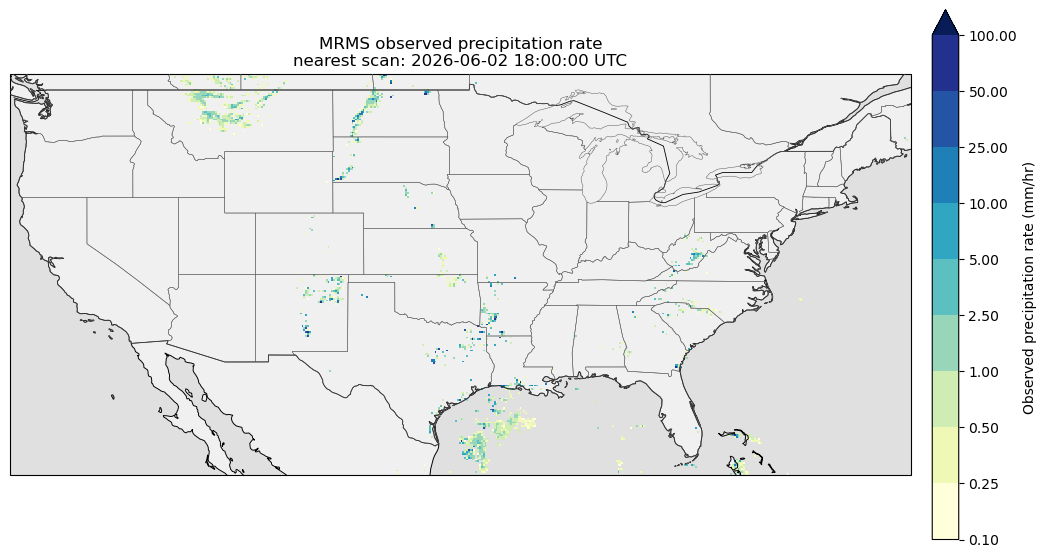

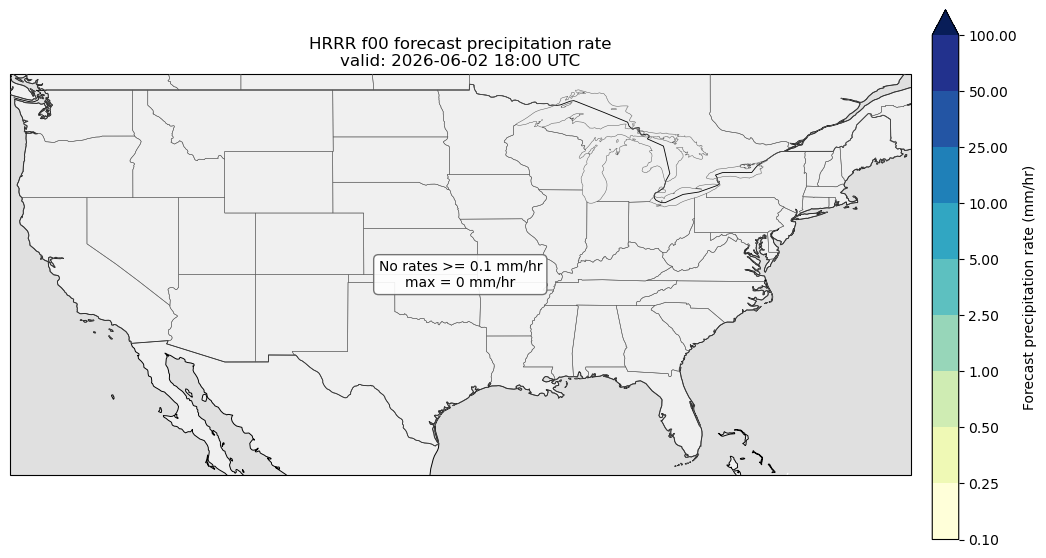

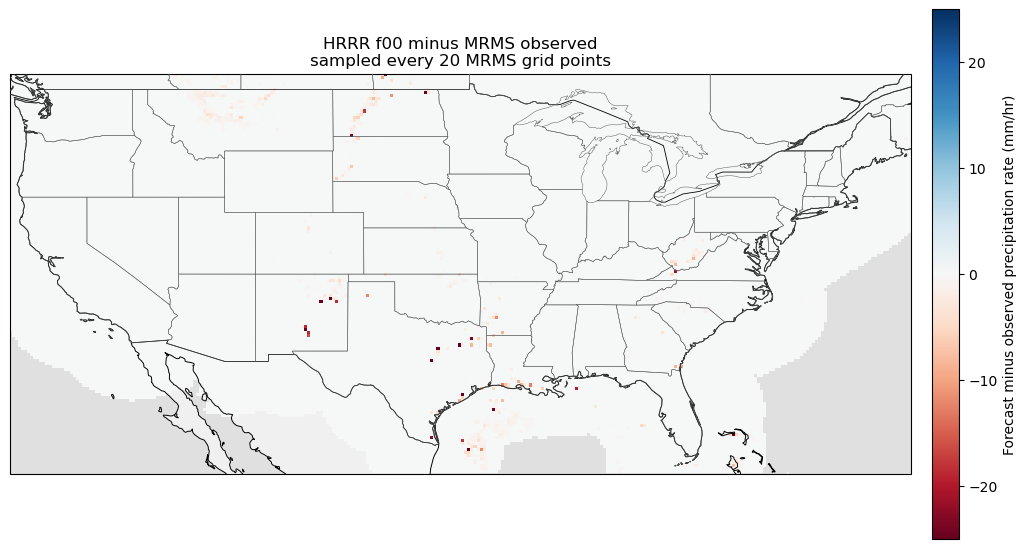

In [7]:
def add_map_features(ax):
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="0.88", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.35", zorder=3)


def print_field_stats(label, data_array, threshold=minimum_display_rate_mm_per_hr):
    values = np.asarray(data_array)
    finite = np.isfinite(values)
    if not np.any(finite):
        print(f"{label}: no finite values")
        return

    finite_values = values[finite]
    above_threshold = finite_values >= threshold
    print(
        f"{label}: min={np.nanmin(finite_values):.4g}, "
        f"max={np.nanmax(finite_values):.4g}, "
        f"mean={np.nanmean(finite_values):.4g} mm/hr, "
        f"points >= {threshold:g} mm/hr={int(above_threshold.sum())}"
    )


def plot_gridded_field(ax, data_array, *, cmap, norm, title, mask_below=None):
    lat, lon = grid_lat_lon(data_array)
    field = data_array
    if mask_below is not None:
        field = field.where(field >= mask_below)
    mesh = ax.pcolormesh(
        lon,
        lat,
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap,
        norm=norm,
        zorder=1,
    )
    add_map_features(ax)
    ax.set_title(title)

    if mask_below is not None and not np.isfinite(np.asarray(field)).any():
        max_rate = float(data_array.max(skipna=True))
        ax.text(
            0.5,
            0.5,
            f"No rates >= {mask_below:g} mm/hr\nmax = {max_rate:.4g} mm/hr",
            ha="center",
            va="center",
            transform=ax.transAxes,
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.4", "alpha": 0.9},
            zorder=5,
        )
    return mesh


valid_label = pd.Timestamp(valid_time_utc).strftime("%Y-%m-%d %H:%M UTC")
mrms_label = pd.Timestamp(mrms_obs.attrs["valid_time_utc"]).strftime("%Y-%m-%d %H:%M:%S UTC")

rate_levels = [0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 10.0, 25.0, 50.0, 100.0]
rate_cmap = plt.get_cmap("YlGnBu", len(rate_levels)).copy()
rate_cmap.set_bad("white", alpha=0.0)
rate_norm = BoundaryNorm(rate_levels, rate_cmap.N, extend="max")

difference_limit = 25.0
diff_cmap = plt.get_cmap("RdBu").copy()
diff_cmap.set_bad("white", alpha=0.0)
diff_norm = TwoSlopeNorm(vmin=-difference_limit, vcenter=0.0, vmax=difference_limit)

mrms_plot = subset_last_two_dimensions(mrms_obs["observed_precip_rate_mm_per_hr"], mrms_plot_stride)
hrrr_plot = subset_last_two_dimensions(hrrr_precip["hrrr_precip_rate_mm_per_hr"], hrrr_plot_stride)

print_field_stats("MRMS observed precipitation rate", mrms_obs["observed_precip_rate_mm_per_hr"])
print_field_stats(f"HRRR f{hrrr_forecast_hour:02d} forecast precipitation rate", hrrr_precip["hrrr_precip_rate_mm_per_hr"])
print_field_stats(
    f"HRRR f{hrrr_forecast_hour:02d} minus MRMS sampled comparison",
    comparison["hrrr_minus_mrms_mm_per_hr"],
    threshold=0.0,
)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = plot_gridded_field(
    ax,
    mrms_plot,
    cmap=rate_cmap,
    norm=rate_norm,
    title=f"MRMS observed precipitation rate\nnearest scan: {mrms_label}",
    mask_below=minimum_display_rate_mm_per_hr,
)
colorbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.86, extend="max")
colorbar.set_label("Observed precipitation rate (mm/hr)")
plt.show()

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = plot_gridded_field(
    ax,
    hrrr_plot,
    cmap=rate_cmap,
    norm=rate_norm,
    title=f"HRRR f{hrrr_forecast_hour:02d} forecast precipitation rate\nvalid: {valid_label}",
    mask_below=minimum_display_rate_mm_per_hr,
)
colorbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.86, extend="max")
colorbar.set_label("Forecast precipitation rate (mm/hr)")
plt.show()

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = plot_gridded_field(
    ax,
    comparison["hrrr_minus_mrms_mm_per_hr"],
    cmap=diff_cmap,
    norm=diff_norm,
    title=f"HRRR f{hrrr_forecast_hour:02d} minus MRMS observed\nsampled every {comparison_stride} MRMS grid points",
)
colorbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.86)
colorbar.set_label("Forecast minus observed precipitation rate (mm/hr)")
plt.show()